### bootstrapping part below

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
    library(Seurat)
    library(tidyr)
})

In [2]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")
options(repr.plot.width = 20, repr.plot.height = 10)

In [3]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"

In [4]:
meta = read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/wildtype_injection/chimera-wt/meta.csv")
meta = meta %>% filter(celltype.mapped != 'Doublet' & celltype.mapped != 'Stripped')
meta = meta %>% filter(stage == 'E8.5')

out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
own_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
own_meta <- own_meta %>% filter(!is.na(own_meta$tdTom))

In [430]:
pdf3 = table(meta$celltype.mapped, meta$tomato)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p1 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20) ,
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [431]:
wt = pdf3

In [432]:
pdf3 = table(own_meta$celltype.mapped, own_meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.00001

p2 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("Mixl1 KO injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20),
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [433]:
ko = pdf3

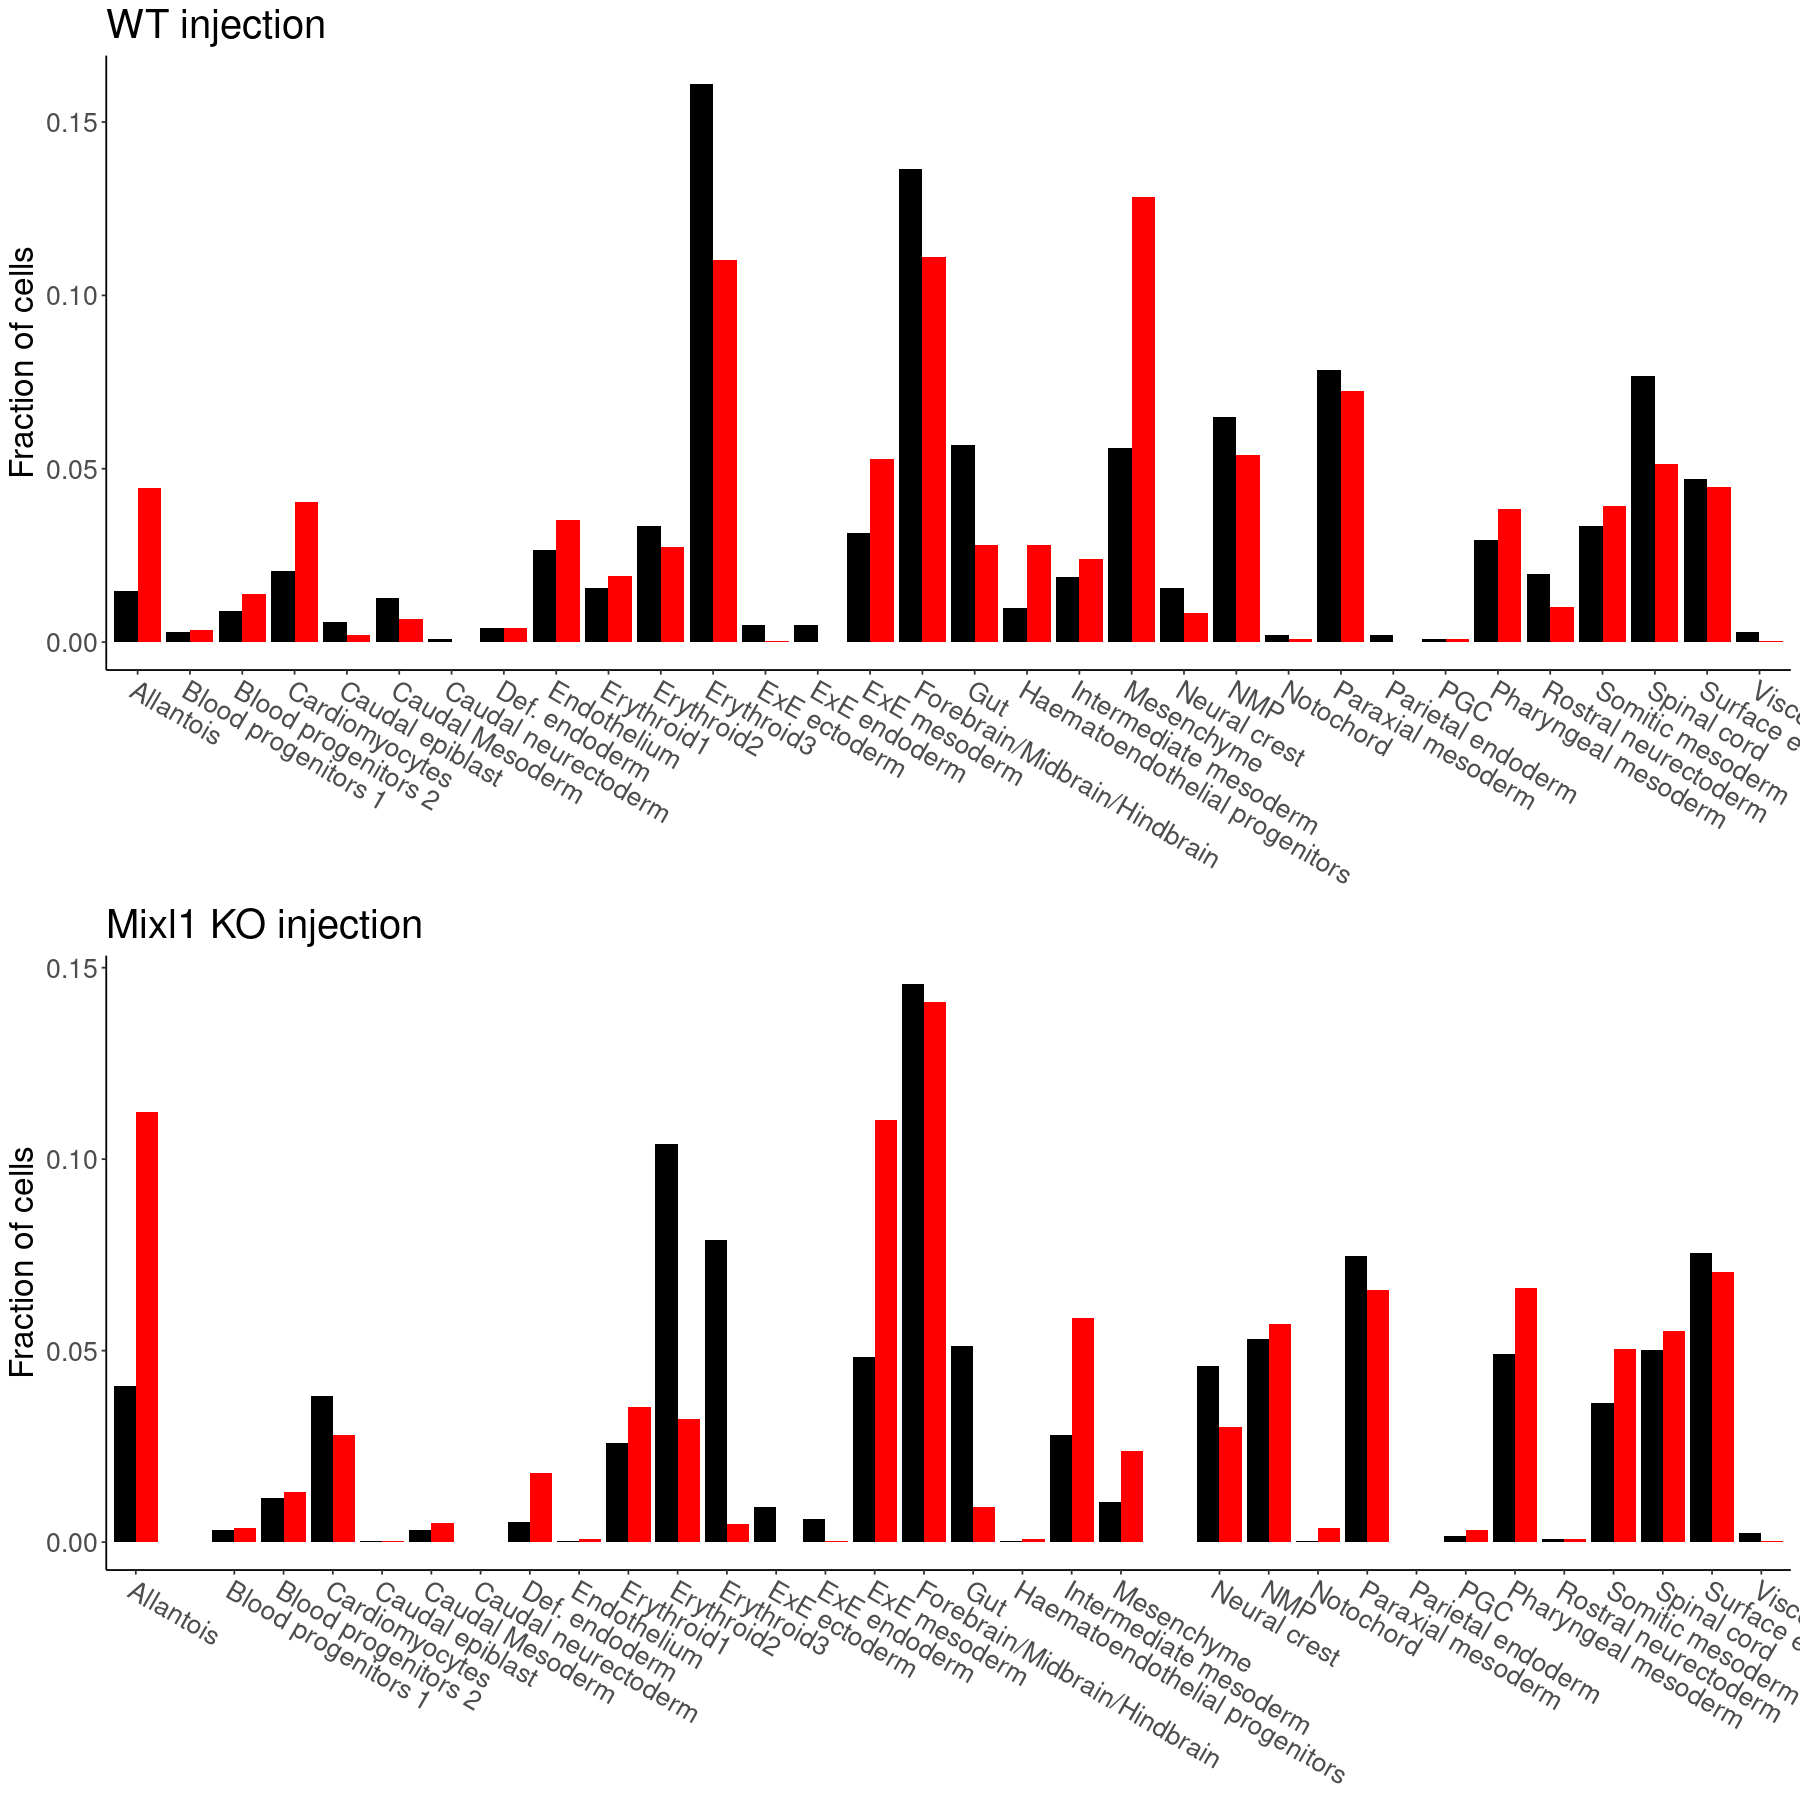

In [434]:
options(repr.plot.width = 15, repr.plot.height = 15)
grid.arrange(p1, p2, nrow =2)

In [435]:
pdf(paste0(plot_folder, "celltype_ko_wt_fraction_comparison.pdf"), height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

png 
  2

In [436]:
head(wt)

,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,Allantois,FALSE,0.014744774
2,Blood progenitors 1,FALSE,0.002956955
3,Blood progenitors 2,FALSE,0.008850864
4,Cardiomyocytes,FALSE,0.020638684
5,Caudal epiblast,FALSE,0.005903910
6,Caudal Mesoderm,FALSE,0.012780138


In [437]:
wt_ratio = spread(wt, Var2, Freq)
colnames(wt_ratio) = c('Var1','host', 'inject')
wt_ratio$ratio_wt = log(wt_ratio$inject/wt_ratio$host)
wt_ratio = wt_ratio %>% select(Var1, ratio_wt)

ko_ratio = spread(ko, Var2, Freq)
colnames(ko_ratio) = c('Var1','host', 'inject')
ko_ratio$ratio_ko = log(ko_ratio$inject/ko_ratio$host)
ko_ratio = ko_ratio %>% select(Var1, ratio_ko)

merged = merge(wt_ratio, ko_ratio, by='Var1')

merged$ratio = abs(merged$ratio_ko/merged$ratio_wt)
merged$sign =  ifelse(merged$ratio_ko < 0,"negative", "positive")
merged$ratio = ifelse(merged$sign == 'negative', -1*merged$ratio, merged$ratio)

In [438]:
head(merged)

,Var1,ratio_wt,ratio_ko,ratio,sign
,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,Allantois,1.1031407,1.0124199,0.9177614,positive
2,Blood progenitors 1,0.1669790,0.1833446,1.0980099,positive
3,Blood progenitors 2,0.4547695,0.1208132,0.2656580,positive
4,Cardiomyocytes,0.6745107,-0.3110904,-0.4612091,negative
5,Caudal epiblast,-0.9927639,-0.3236718,-0.3260310,negative
6,Caudal Mesoderm,-0.6694810,0.4112809,0.6143280,positive


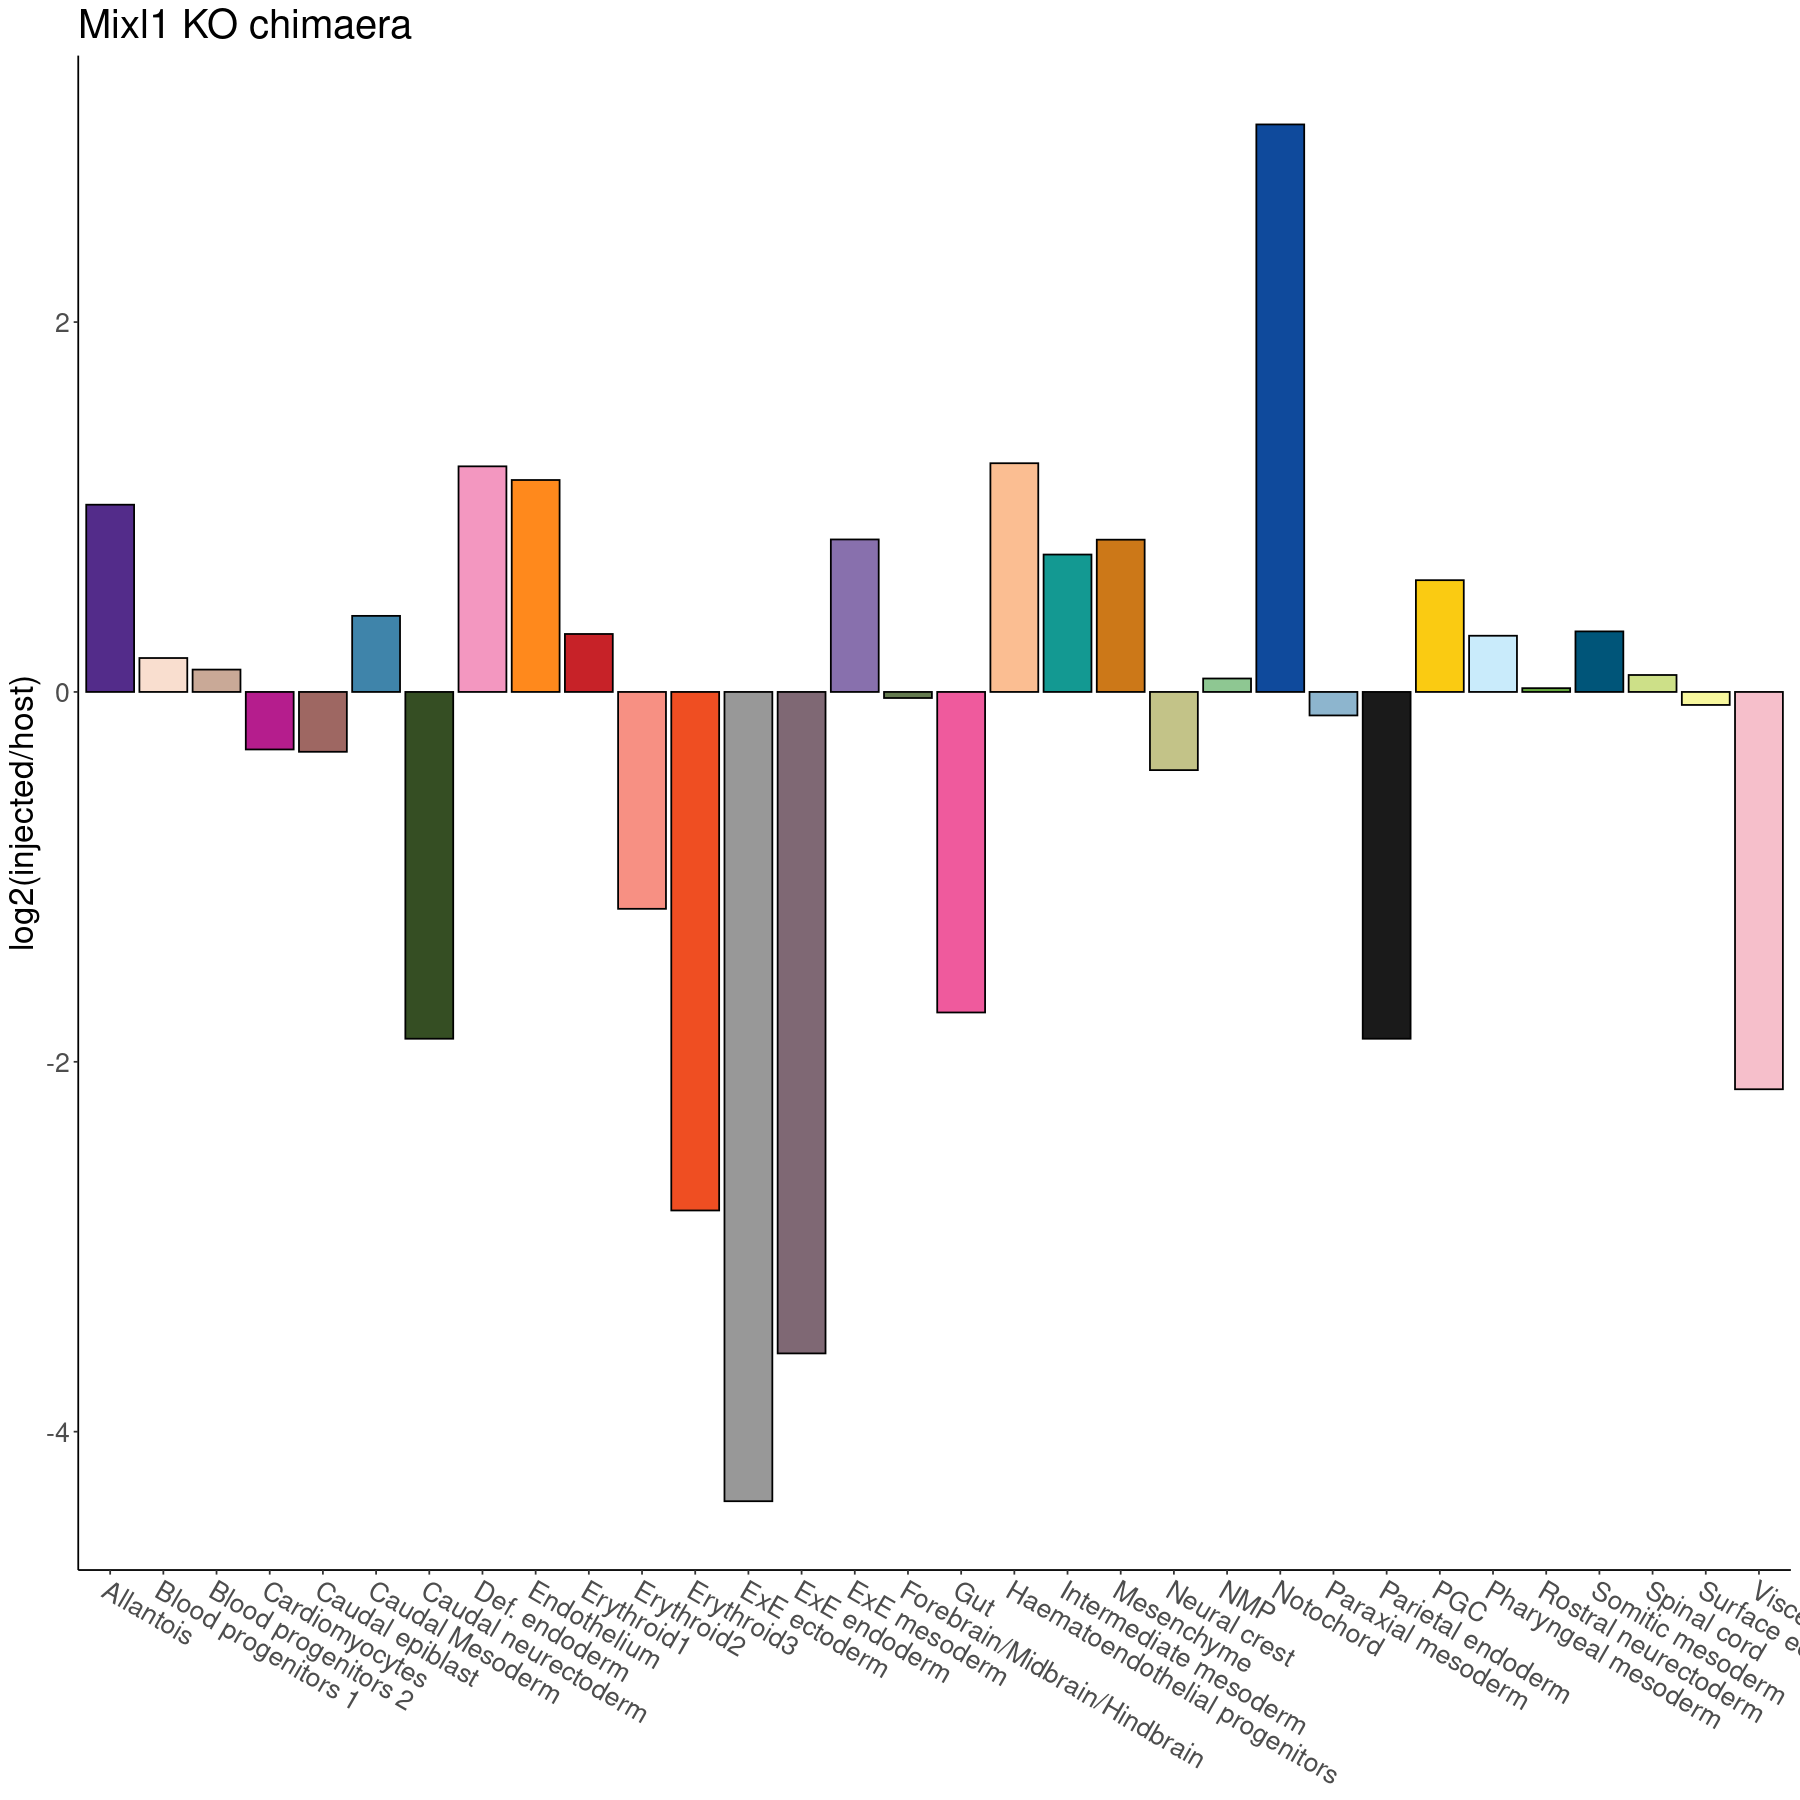

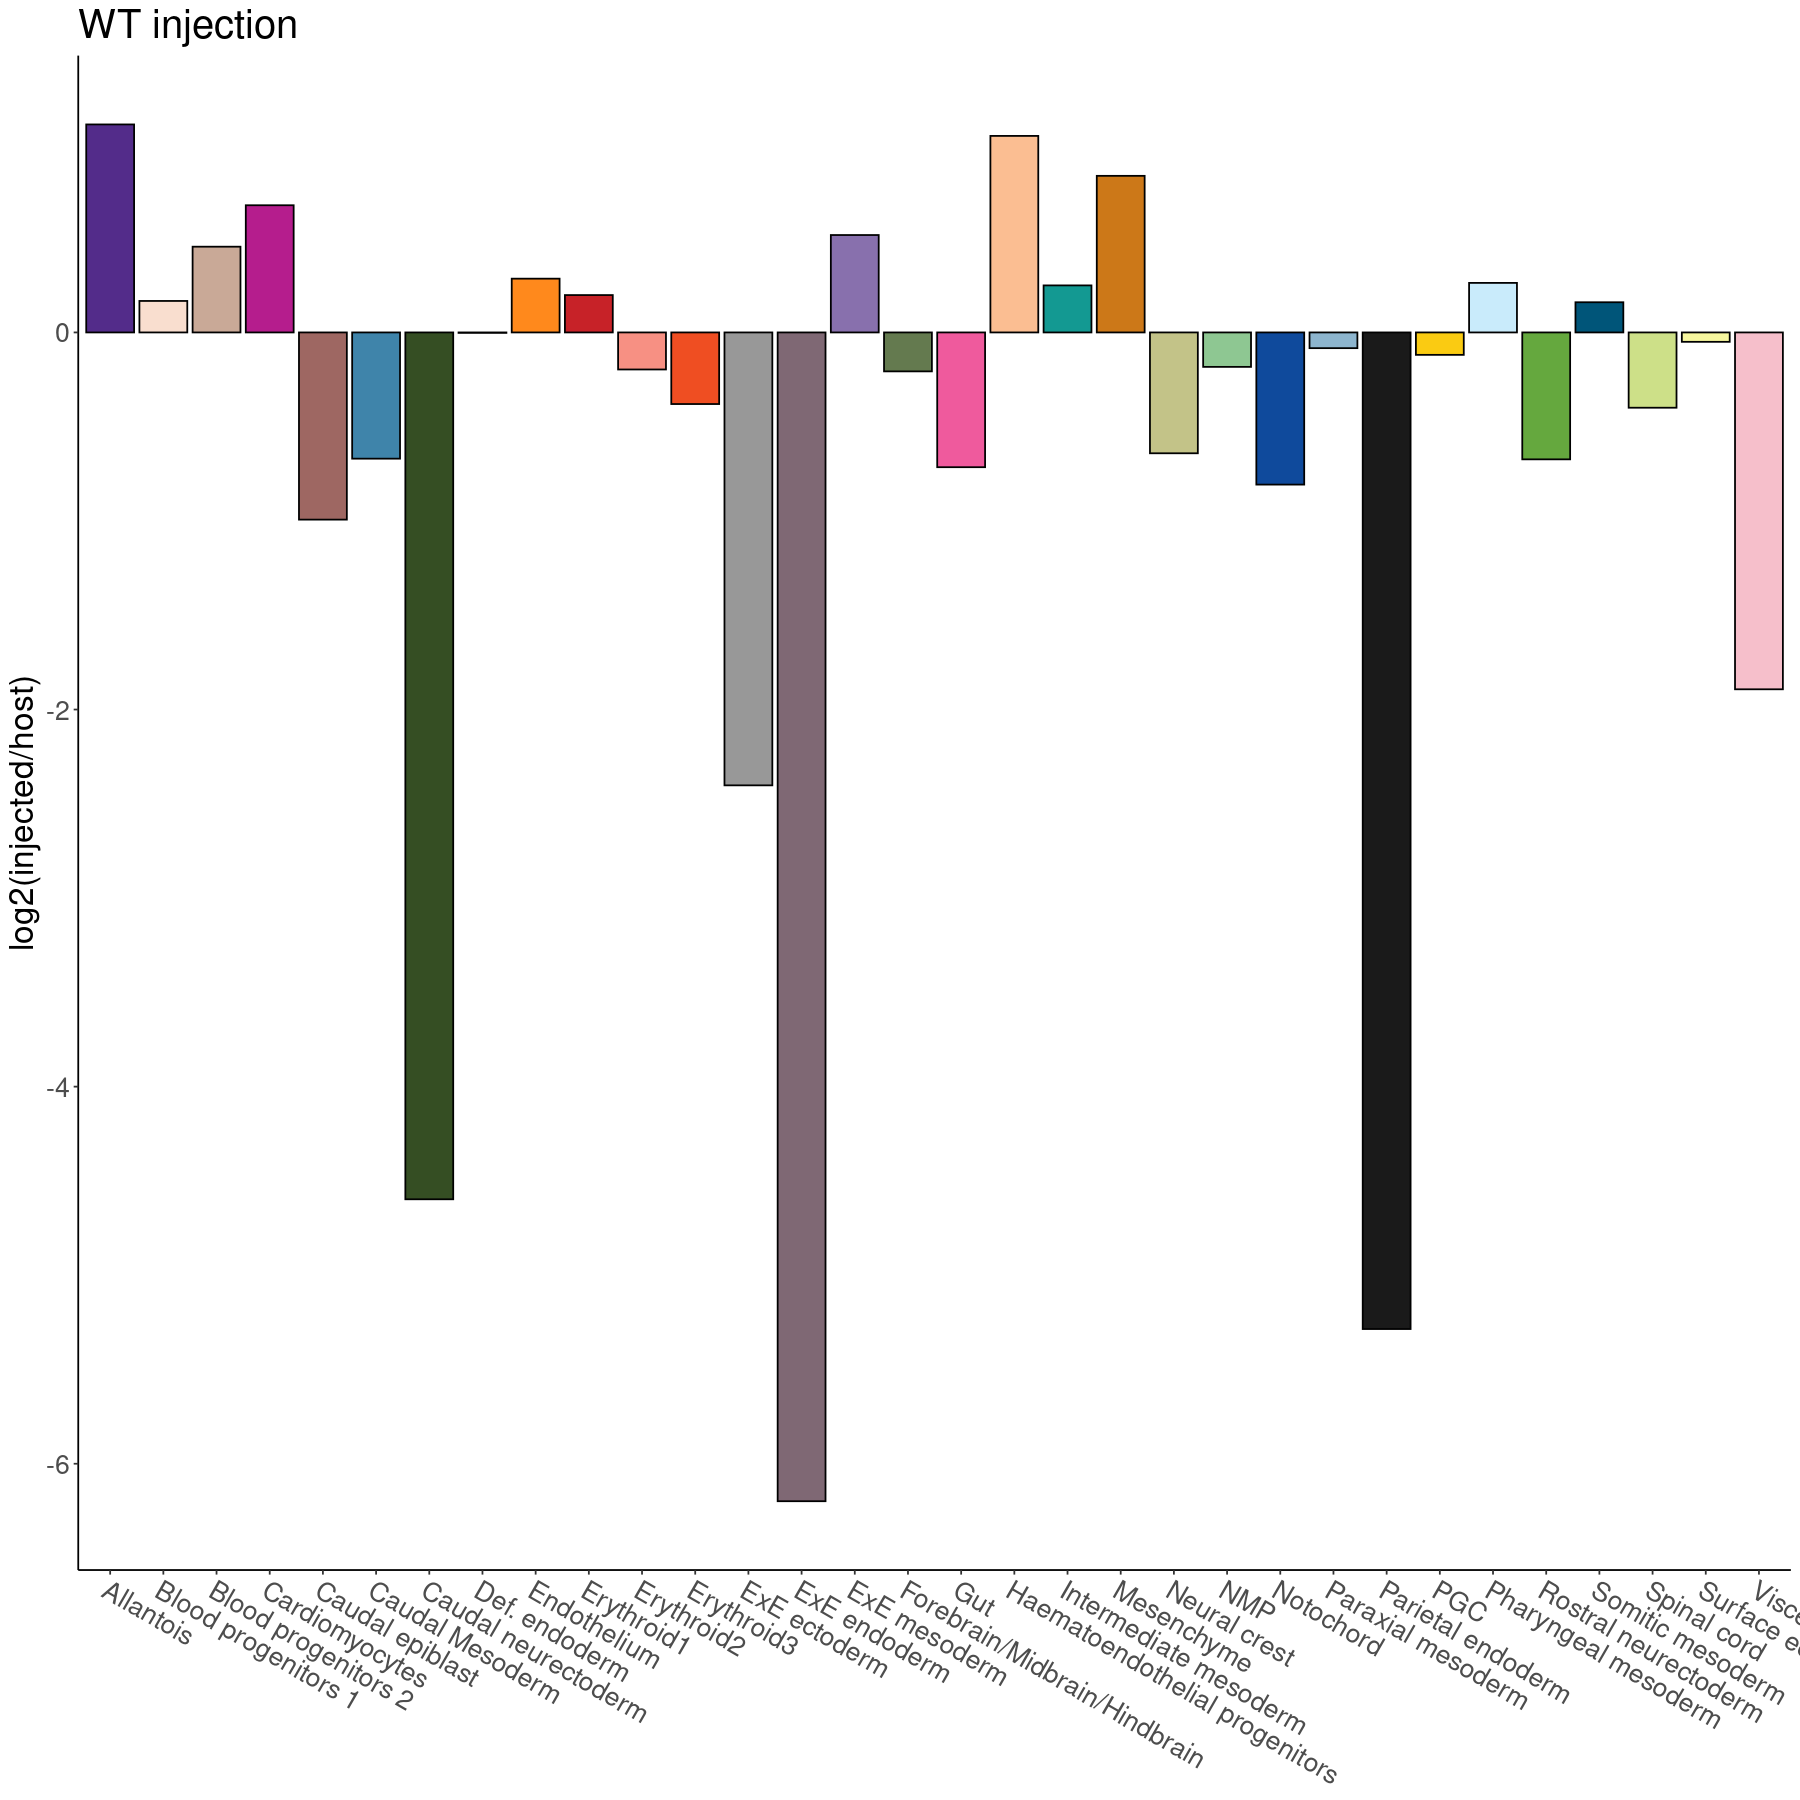

In [439]:
#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p1 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_ko, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
p1

p2 = ggplot(data = merged, mapping = aes(x = Var1, y = ratio_wt, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
p2

In [137]:
pdf(paste0(plot_folder, "celltype_ko_wt_ratio.pdf"), height=14, width=15)
    grid.arrange(p1, p2, nrow =2)
dev.off()

png 
  2

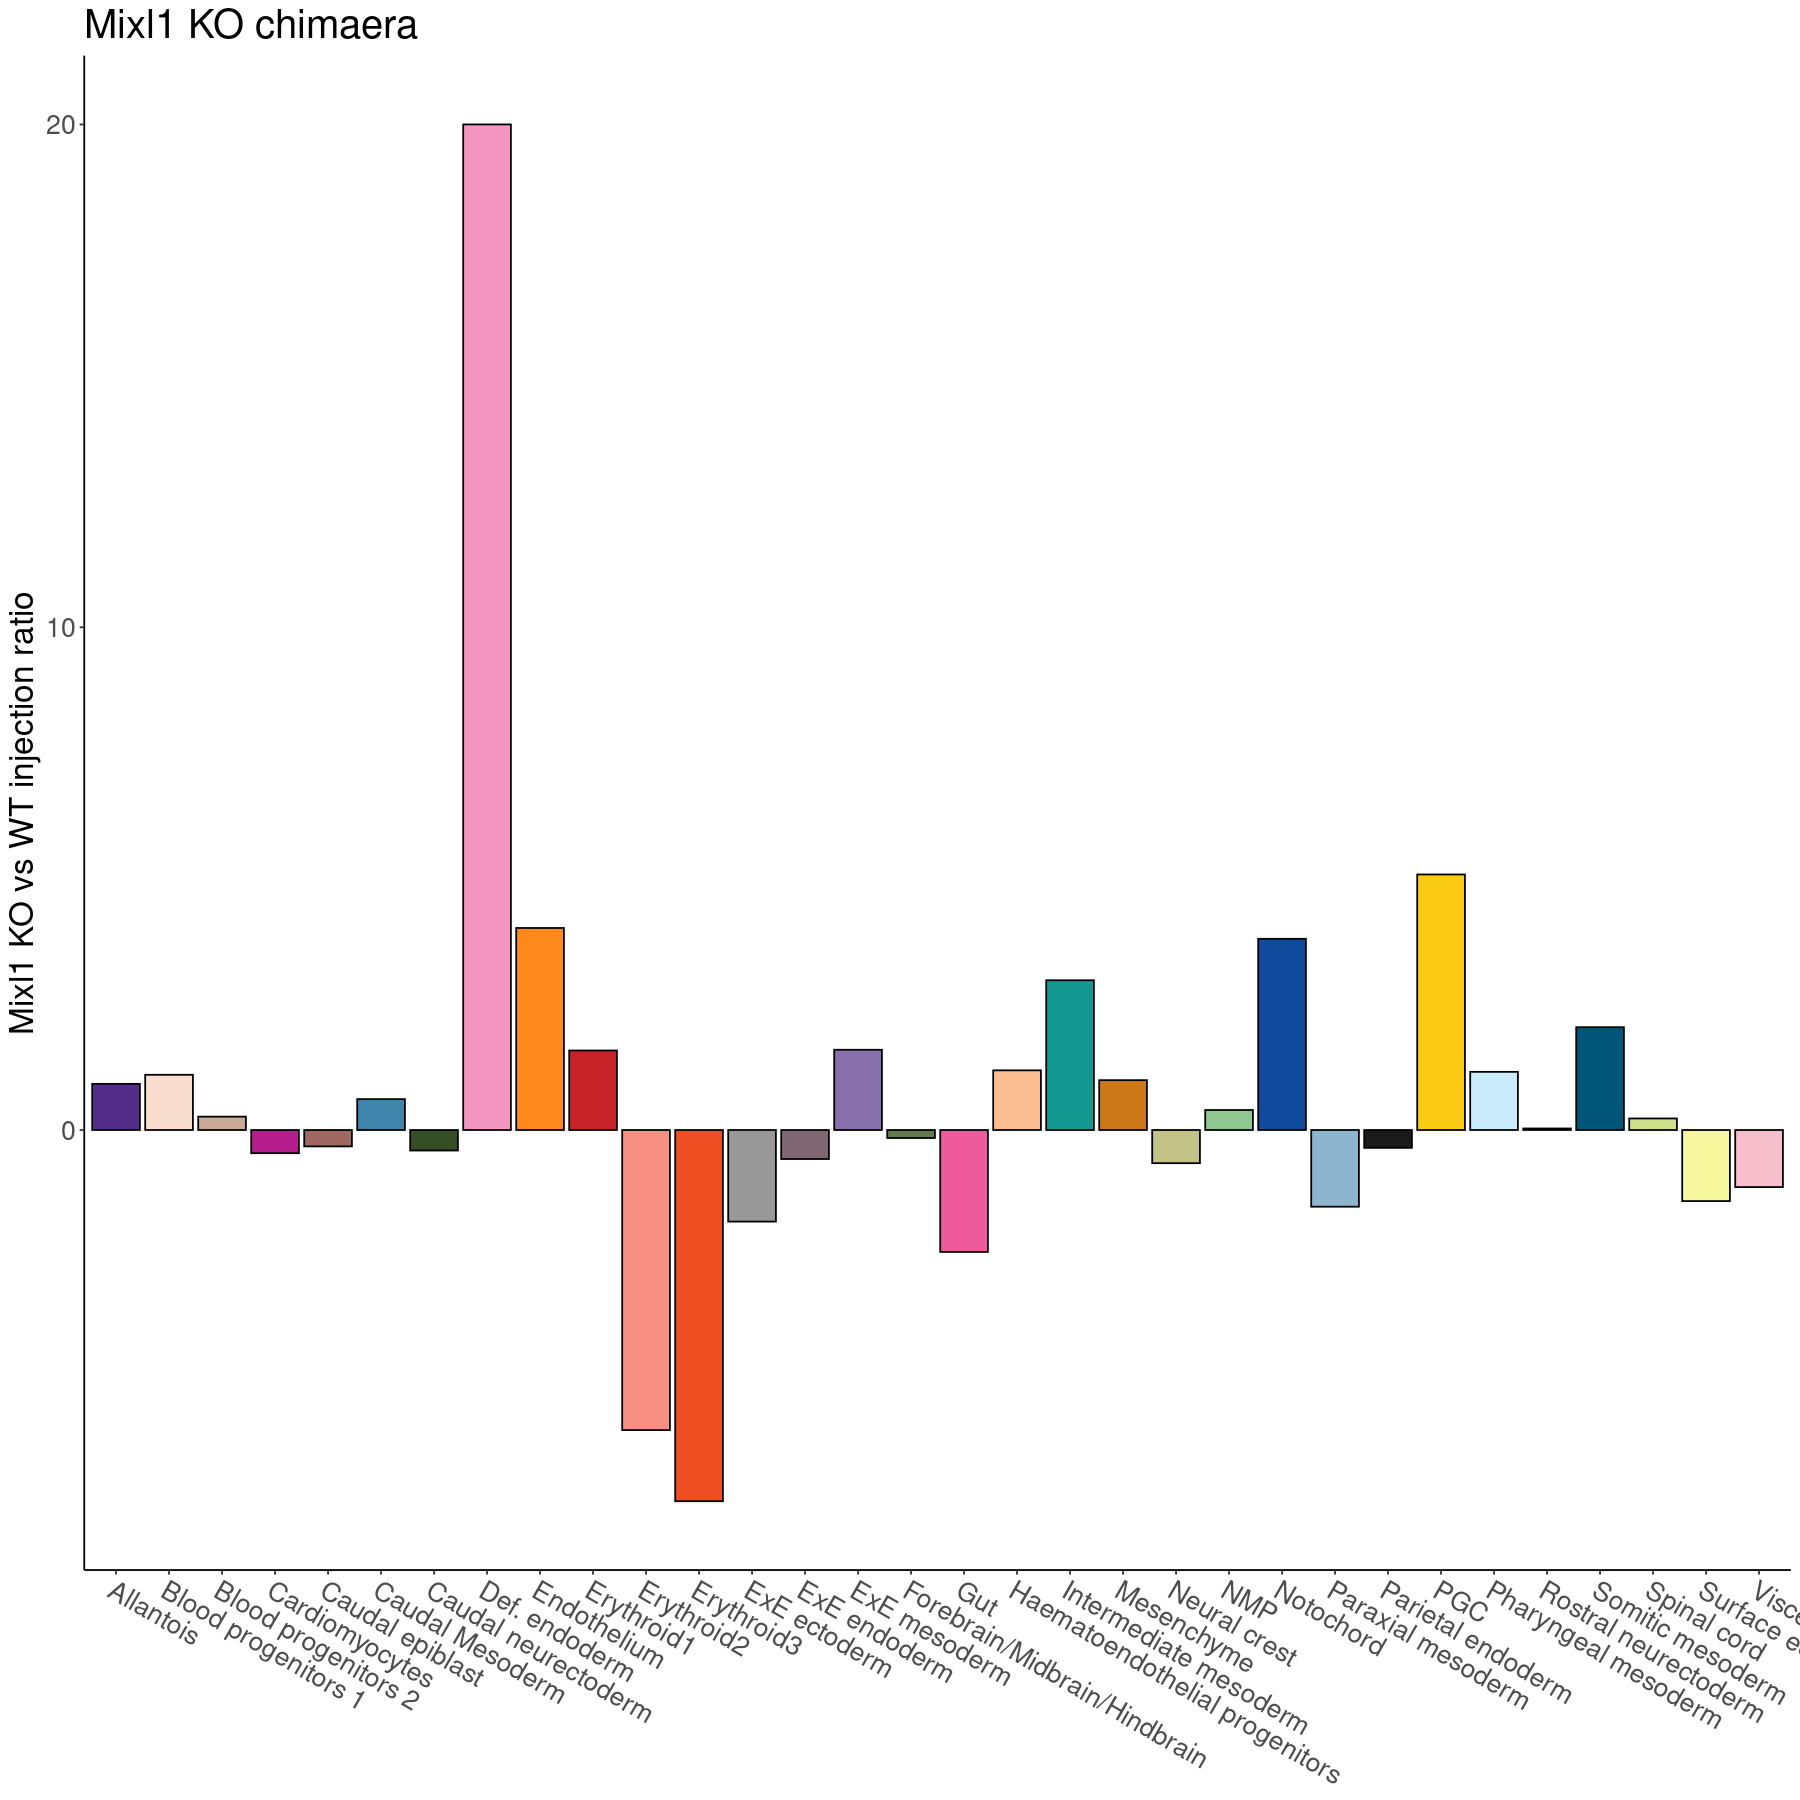

In [440]:
merged_maxed = merged
merged_maxed$ratio = ifelse(merged_maxed$ratio > 20, 20, merged_maxed$ratio)

p = ggplot(data = merged_maxed, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "Mixl1 KO vs WT injection ratio") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

p

In [441]:
pdf(paste0(plot_folder, "celltype_injection_ratio.pdf"), height=8, width=15)
    p
dev.off()

png 
  2

In [442]:
merged2 = gather(merged, exp, ratio, -Var1, -ratio, -sign)

In [443]:
head(merged2)

,Var1,sign,exp,ratio
,<fct>,<chr>,<chr>,<dbl>
1,Allantois,positive,ratio_wt,1.1031407
2,Blood progenitors 1,positive,ratio_wt,0.1669790
3,Blood progenitors 2,positive,ratio_wt,0.4547695
4,Cardiomyocytes,negative,ratio_wt,0.6745107
5,Caudal epiblast,negative,ratio_wt,-0.9927639
6,Caudal Mesoderm,positive,ratio_wt,-0.6694810


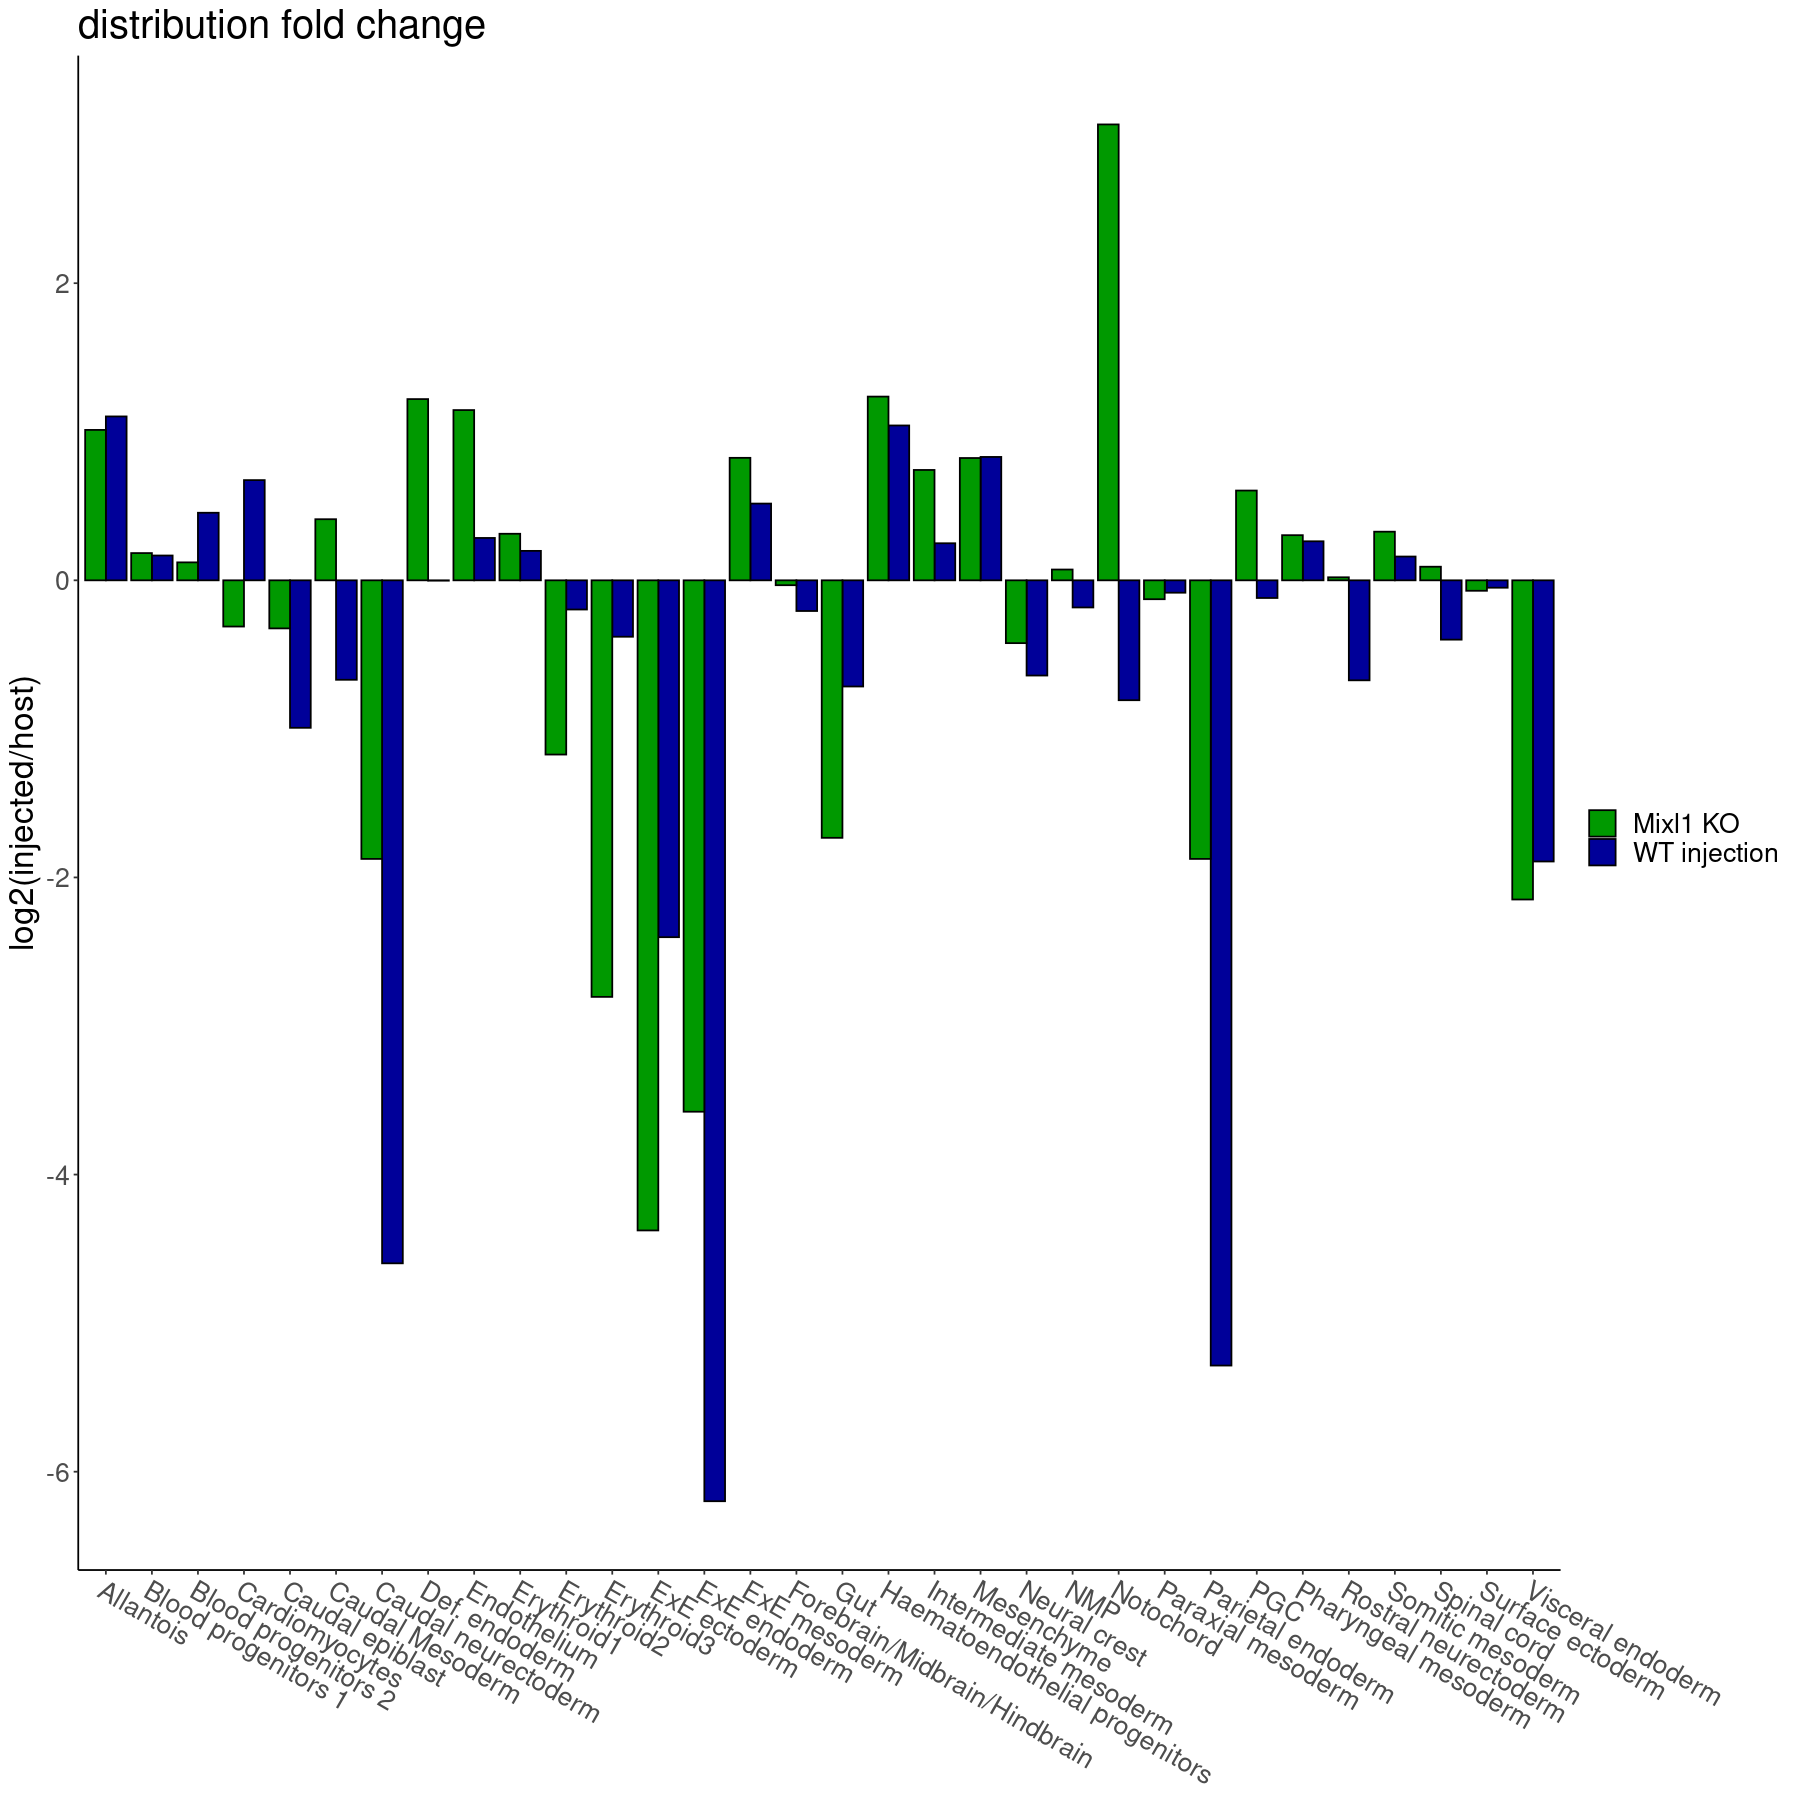

In [444]:
#merged_stripped = merged %>% filter(Var1 != 'Mixed mesoderm')
p = ggplot(data = merged2, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("ratio_ko" = "#009900", "ratio_wt" = "#000099"), 
                    labels = c("ratio_ko" = "Mixl1 KO", "ratio_wt" = "WT injection"),
                    name = "") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
p

In [139]:
pdf(paste0(plot_folder, "celltype_ko_wt_ratio_side.pdf"), height=8, width=15)
    p
dev.off()

png 
  2

In [447]:
# exclude low cell nr
own_meta$count = 1
counts = own_meta %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
# exclude ExE
exe = c('ExE ectoderm', 'ExE endoderm', 'Visceral endoderm', 'Parietal endoderm')
exclude = counts %>% filter(count < 40 | celltype.mapped %in% exe) %>% .$celltype.mapped


`summarise()` ungrouping output (override with `.groups` argument)



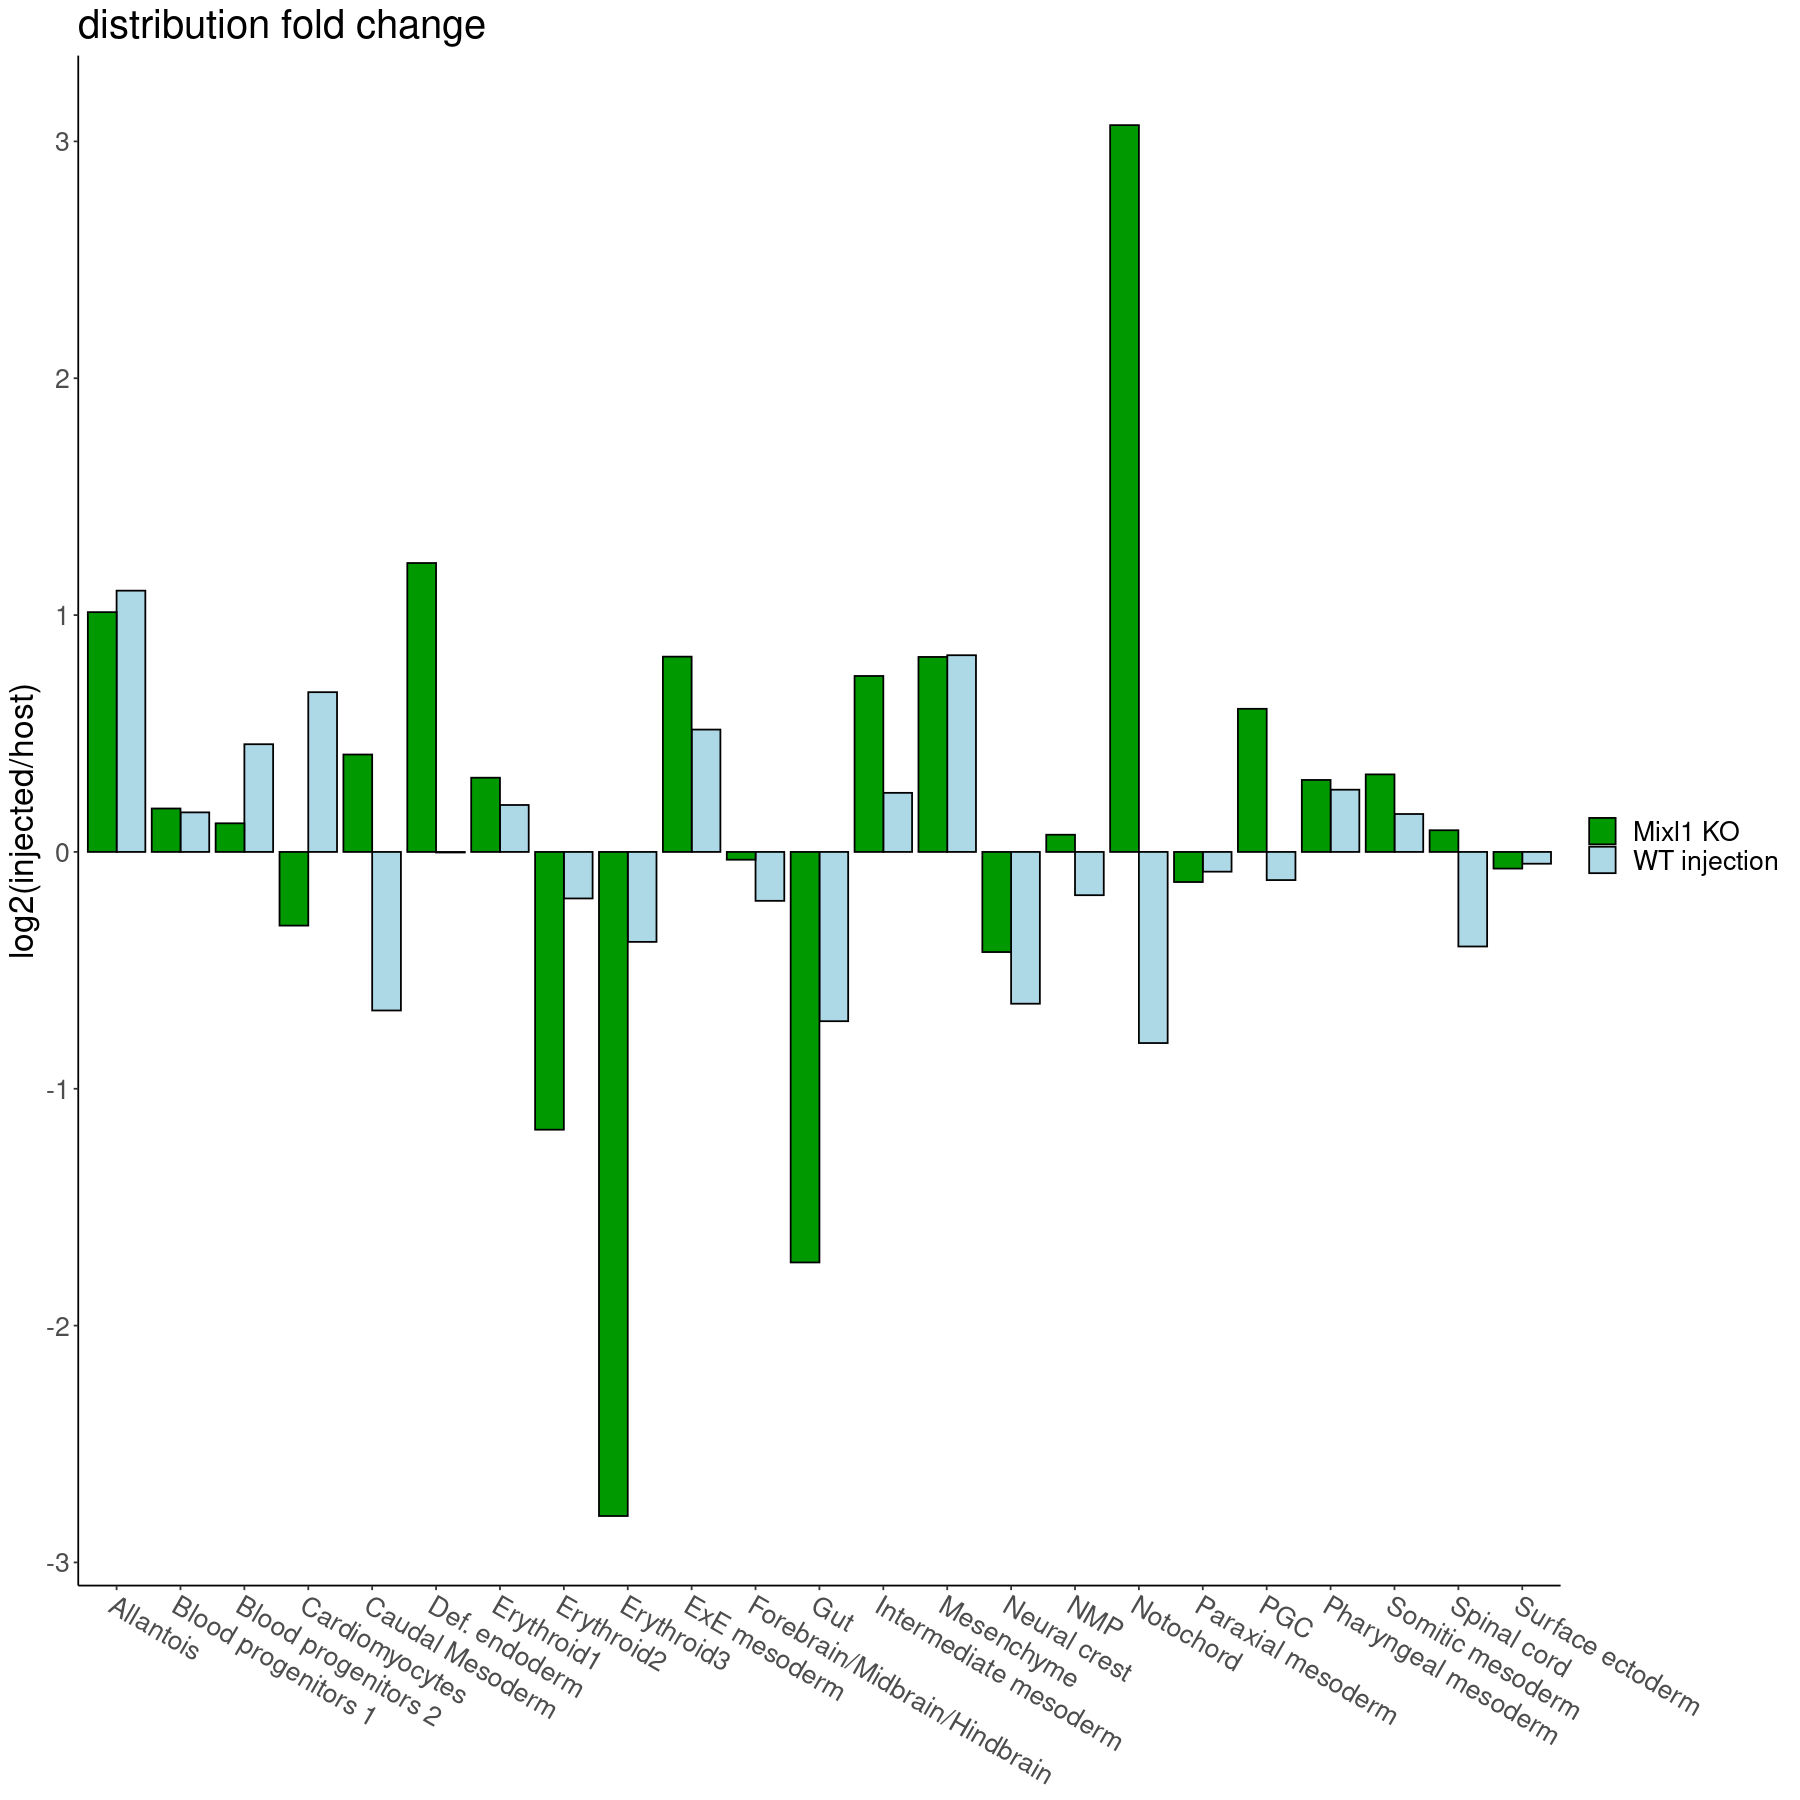

In [450]:
merged_stripped = merged2 %>% filter(!Var1 %in% exclude)
p = ggplot(data = merged_stripped, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("ratio_ko" = "#009900", "ratio_wt" = "#add8e6"), 
                    labels = c("ratio_ko" = "Mixl1 KO", "ratio_wt" = "WT injection"),
                    name = "") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
p

In [451]:
pdf(paste0(plot_folder, "celltype_ko_wt_ratio_side_no_exe.pdf"), height=8, width=15)
    p
dev.off()

png 
  2

## Bootstrapping to get errors

meta needs to be loaded for scales

In [5]:
WT = read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/wildtype_injection/chimera-wt/meta.csv")
WT = WT %>% filter(celltype.mapped != 'Doublet' & celltype.mapped != 'Stripped')
WT = WT %>% filter(stage == 'E8.5')

out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
KO = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
KO <- KO %>% filter(!is.na(KO$tdTom))

In [6]:
# put WT and KO in same format
KO$tomato <- KO$tdTom
KO$tomato =  ifelse(KO$tomato == 'pos',TRUE, FALSE)

In [7]:
#define functions

boot = function(df, k){
    big = KO %>% select(celltype.mapped, tomato) %>% distinct() %>% arrange(celltype.mapped)
    colnames(big) = c('Var1', 'Var2')
    
    rownames(df) = df$cell
    
    # Caclulate mean from all data before bootstrapping
    pdf_mean = table(df$celltype.mapped, df$tomato)
    pdf_mean = as.data.frame(sweep(pdf_mean, 2, colSums(pdf_mean), "/"))
    colnames(pdf_mean) = c('Var1', 'Var2', 'mean') # renamed to mean to make compatible with other code
    
    # Calculate SD via bootstrapping
    for(i in 1:k){ # iterate k times
        subset_cells = sample(df$cell, replace = TRUE) # random sampling with replacements
        subset = df[subset_cells,]
        pdf1 = table(subset$celltype.mapped, subset$tomato)
        pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
     #   pdf1$Freq = pdf1$Freq + 0.00001
        colnames(pdf1) = c('Var1', 'Var2', paste0('Freq_', i))
        big = merge(big, pdf1, by=c('Var1', 'Var2'), all.x=TRUE)
    }
    big[is.na(big)] <- 0 # NA = 0
    long = gather(big, sample, frequency, Freq_1:colnames(big[length(big)]), -Var1, -Var2)
    sd = long %>% group_by(Var1, Var2) %>% summarize(sd = sd(frequency, na.rm = TRUE))

    mean_sd = merge(pdf_mean, sd, by=c('Var1', 'Var2'), all.x=TRUE) # merge mean with sd
    
    big = KO %>% select(celltype.mapped, tomato) %>% distinct() %>% arrange(celltype.mapped)
    colnames(big) = c('Var1', 'Var2')
    mean_sd = merge(big, mean_sd, by=c('Var1', 'Var2'), all.x=TRUE)
    mean_sd[is.na(mean_sd)] <- 0
    
    return(mean_sd)
   # return(big)
    
}

plot_freq = function(df, title){
  ggplot(data = df, mapping = aes(x = Var1, y = mean, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle(paste0(title, ' injection frequencies')) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])
}

ratio = function(df, original){
    means = df %>% select(Var1, Var2, mean)
    ratio_mean = spread(means, Var2, mean)
    colnames(ratio_mean) = c('Var1', 'host', 'inject')
    ratio_mean$ratio = log2(ratio_mean$inject / ratio_mean$host) # log2 or log?
    ratio_mean_bu = ratio_mean
    ratio_mean = ratio_mean %>% select(Var1, ratio)

    error = df %>% select(Var1, Var2, sd)
    ratio_error = spread(error, Var2, sd)
    colnames(ratio_error) = c('Var1', 'host', 'inject')
    ratio_error$sd = ratio_mean$ratio*sqrt((ratio_error$inject/ratio_mean_bu$inject)^2 + (ratio_error$host/ratio_mean_bu$host)^2)
    #ratio_error$sd = log(ratio_error$inject / ratio_error$host)
    ratio_error = ratio_error %>% select(Var1, sd)

    original$count = 1
    counts = original %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
    colnames(counts) = c('Var1', 'ncells')
    ratio_error = merge(ratio_error, counts, by='Var1')
    ratio_error$sd = ratio_error$sd / sqrt(ratio_error$ncells) # calculate SEM from propagated error
    
    ratio_final = merge(ratio_mean, ratio_error, by='Var1')
    
#     big = KO %>% select(celltype.mapped) %>% distinct() %>% arrange(celltype.mapped)
#     colnames(big) = c('Var1')
#     ratio_final = merge(big, ratio_final, by=c('Var1'), all.x=TRUE)
#     ratio_final[is.na(ratio_final)] <- 0 # NA = 0
    
    return(ratio_final)
}

plot_ratio = function(df, title){
    ggplot(data = df, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
      geom_bar(stat = "identity", position = "dodge", color='black') +
      labs(x = "Atlas celltype", y = "log2(injected/host)") +
      ggtitle(paste0(title, ' injection fold change')) +
      theme_classic() +
      theme(axis.text.x = element_text(angle = -30, hjust = 0),
            legend.position = "none", text = element_text(size = 20), 
            axis.title.x = element_blank()) +
       geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                     position=position_dodge(.9)) +
      scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
      scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])
}

combine = function(df1, df2) {
    colnames(df1) = c('Var1', 'ratio_df1', 'sd_df1', 'ncells_df1')#, 'sd_corr_df1')
    colnames(df2) = c('Var1', 'ratio_df2', 'sd_df2', 'ncells_df2')#, 'sd_corr_df2')
    
    df1_ratio = df1 %>% select('Var1', 'ratio_df1')
    df2_ratio = df2 %>% select('Var1', 'ratio_df2')
    merge_ratio = merge(df1_ratio, df2_ratio, by=c('Var1'))
    merge_ratio = gather(merge_ratio, exp, ratio, -Var1)
    merge_ratio$exp = str_replace(merge_ratio$exp, 'ratio_', '')

    df1_sd = df1 %>% select('Var1', 'sd_df1')
    df2_sd = df2 %>% select('Var1', 'sd_df2')
    merge_sd = merge(df1_sd, df2_sd, by=c('Var1'))
    merge_sd = gather(merge_sd, exp, sd, -Var1)
    merge_sd$exp = str_replace(merge_sd$exp, 'sd_', '')
    
#     df1_sd_corr = df1 %>% select('Var1', 'sd_corr_df1')
#     df2_sd_corr = df2 %>% select('Var1', 'sd_corr_df2')
#     merge_sd_corr = merge(df1_sd_corr, df2_sd_corr, by=c('Var1'))
#     merge_sd_corr = gather(merge_sd_corr, exp, sd_corr, -Var1)
#     merge_sd_corr$exp = str_replace(merge_sd_corr$exp, 'sd_corr_', '')
    
    merge = merge(merge_ratio, merge_sd, by=c('Var1', 'exp'))
#     merge = merge(merge, merge_sd_corr, by=c('Var1', 'exp'))
    return(merge)
}

plot_combined = function(df){
    ggplot(data = df, mapping = aes(x = Var1, y = ratio, fill=exp)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("distribution fold change") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  scale_fill_manual(values = c("df2" = "#009900", "df1" = "#add8e6"), 
                    labels = c("df2" = "Mixl1 KO", "df1" = "WT injection"),
                    name = "") +
  geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])   
}

In [8]:
# exclude extremely low cell nr
KO$count = 1
counts = KO %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
celltypes.keep = counts %>% filter(count > 5) %>% .$celltype.mapped

wt = boot(WT, 1000)
wt = wt %>% filter(Var1 %in% celltypes.keep)
wt_ratio = ratio(wt, WT)

ko = boot(KO, 1000)
ko = ko %>% filter(Var1 %in% celltypes.keep)
ko_ratio = ratio(ko, KO)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)



In [10]:
combined = combine(wt_ratio, ko_ratio)

# exclude low cell nr
KO$count = 1
counts = KO %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
# exclude ExE
exe = c('ExE ectoderm', 'ExE endoderm', 'Visceral endoderm', 'Parietal endoderm')
exclude = counts %>% filter(count < 40 | celltype.mapped %in% exe) %>% .$celltype.mapped
combined_no_weird = combined %>% filter(!Var1 %in% exclude)

`summarise()` ungrouping output (override with `.groups` argument)



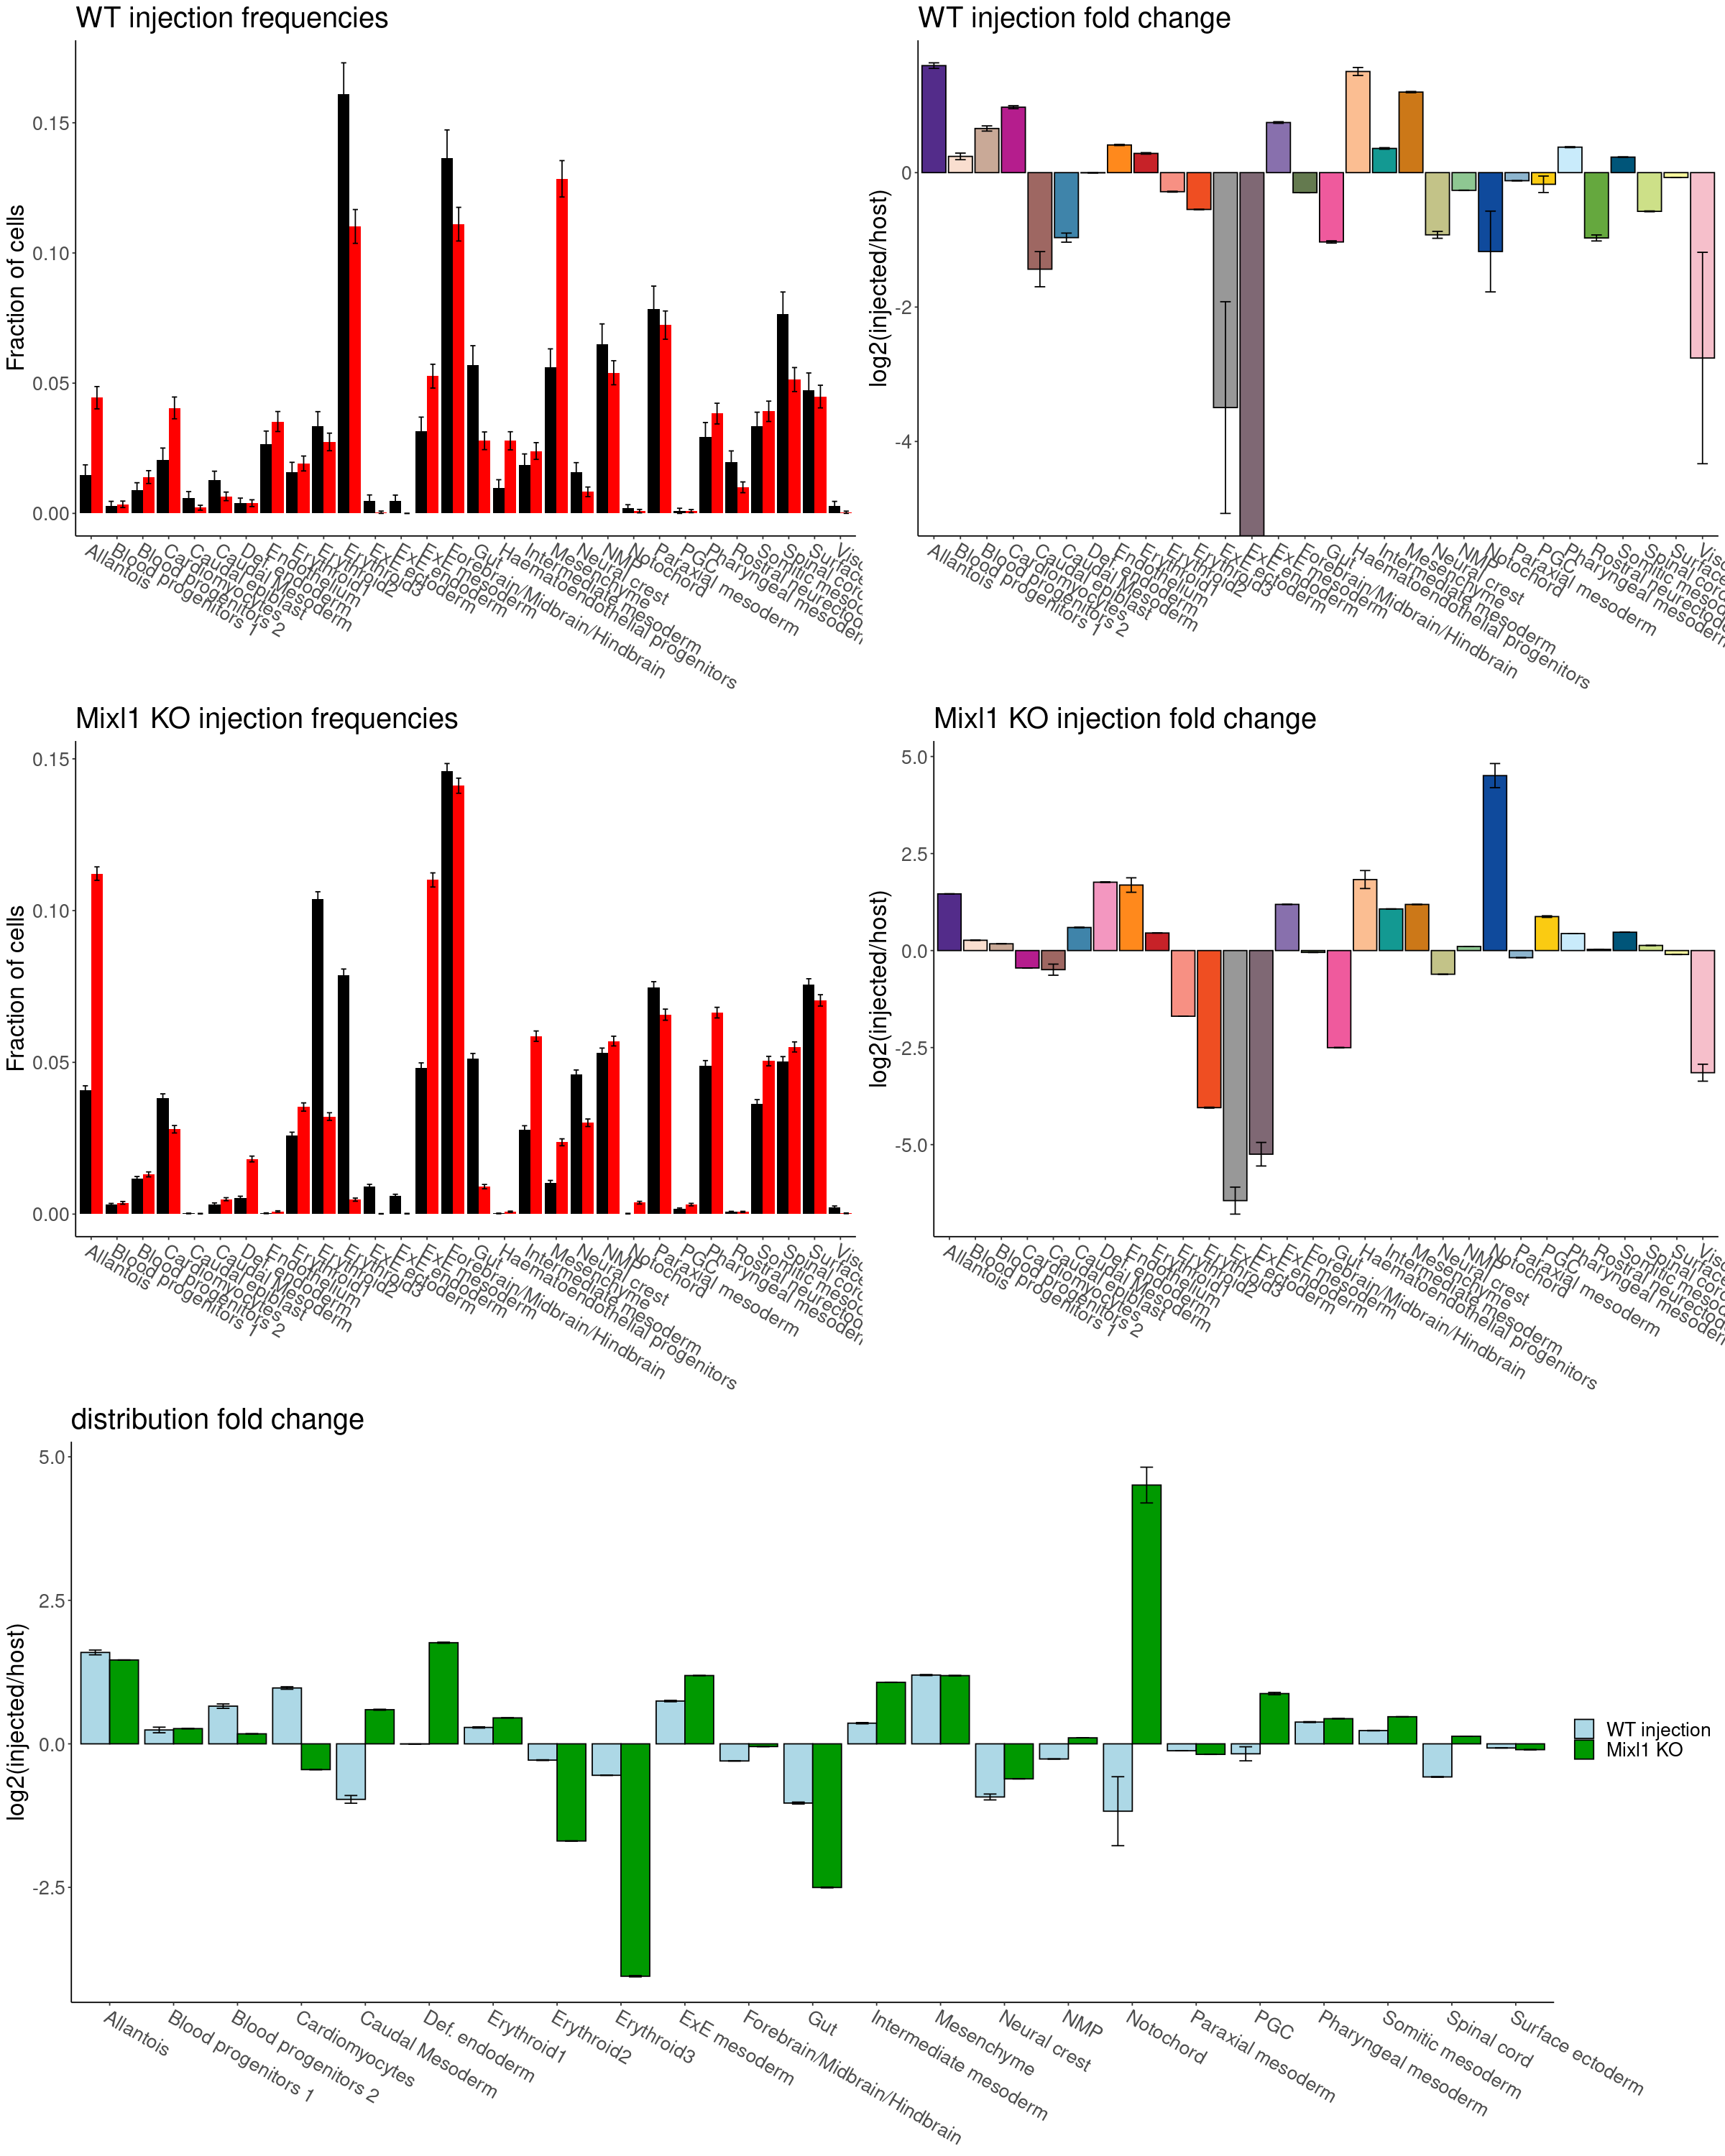

In [11]:
# using propagated error before n cell correction
p1 = plot_freq(wt, 'WT')
p2 = plot_ratio(wt_ratio, 'WT')
p3 = plot_freq(ko, 'Mixl1 KO')
p4 = plot_ratio(ko_ratio, 'Mixl1 KO')

options(repr.plot.width = 20, repr.plot.height = 25)
p = plot_grid(plot_grid(p1, p2, p3, p4, ncol = 2), plot_combined(combined_no_weird), rel_heights = c(0.65, 0.35), nrow = 2)
p

In [17]:
pdf(paste0(plot_folder, "distribution_proper_SEM.pdf"), height=20, width=25)
    p
dev.off()

pdf(paste0(plot_folder, "distribution_frequencies.pdf"), height=15, width=15)
    plot_grid(p3, p1, nrow = 2)
dev.off()

pdf(paste0(plot_folder, "distribution_fold.pdf"), height=15, width=15)
    plot_grid(p4, p2, nrow = 2)
dev.off()

pdf(paste0(plot_folder, "distribution_fold_changes_SEM.pdf"), height=8, width=15)
    plot_combined(combined_no_weird)
dev.off()

png 
  2

png 
  2

png 
  2

png 
  2

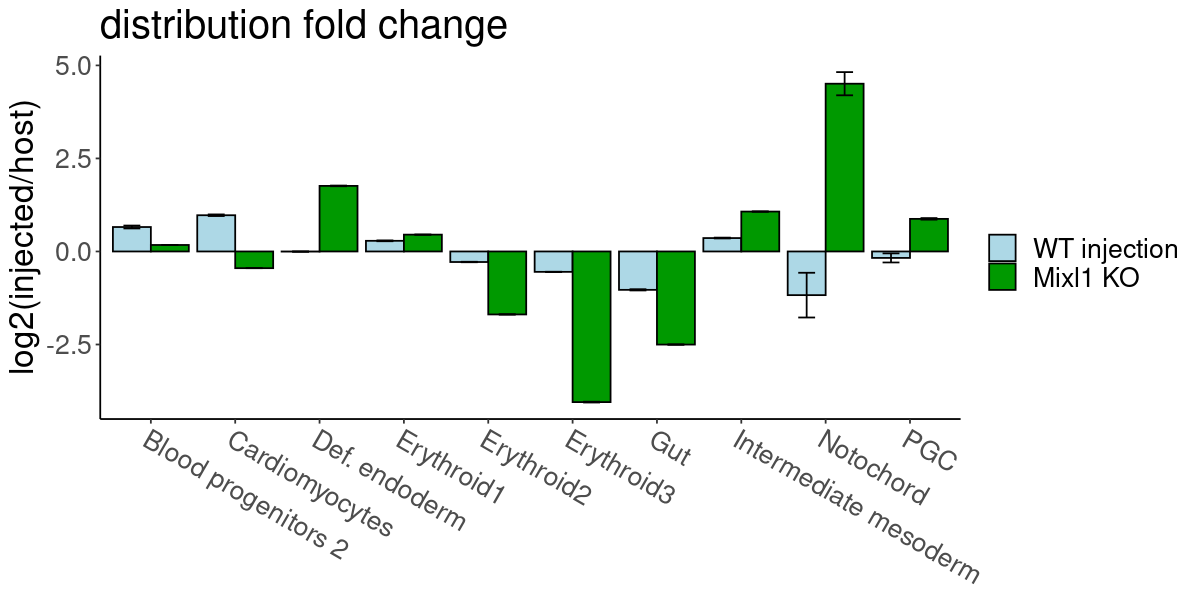

In [18]:
# plot only celltypes that are affected
include = c('Blood progenitors 2', 'Cardiomyocytes', 'Def. endoderm', 'Erythroid1', 'Erythroid2', 'Erythroid3', 'Gut', 'Intermediate mesoderm', 'Notochord', 'PGC')
combined_important = combined_no_weird %>% filter(Var1 %in% include)

options(repr.plot.width = 10, repr.plot.height = 5)
plot_combined(combined_important)

In [19]:
pdf(paste0(plot_folder, "distribution_fold_changes_important_SEM.pdf"), height=5, width=10)
    plot_combined(combined_important)
dev.off()

png 
  2